# Adaptive Cost-Aware Context Selection (ACCS)

## Repository-Level Context Optimization for LLM Coding Agents

This notebook implements and evaluates an Adaptive Cost-Aware Context Selection (ACCS) algorithm.

The objective is to reduce token usage while preserving important dependency relationships within a repository.

Two approaches are compared:
1. Baseline Breadth-First Search (BFS)
2. Proposed ACCS algorithm

### How to Run

This notebook is fully self-contained and independent. It uses the actual production implementation from the project:
- `parser.ast_parser` - AST parsing
- `graph.graph_builder` - Dependency graph construction
- `retrieval.baseline_bfs` - Baseline BFS retrieval
- `retrieval.adaptive_budget` - Adaptive budget-aware retrieval
- `metrics.*` - Token estimation, context building, coverage metrics

Just ensure the project root is in your Python path and run all cells.

In [15]:
# Add project root to Python path (ensures imports work from any location)
import sys
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    PROJECT_ROOT = Path("/home/dilusha/projects/BGCR")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Standard libraries
import os
import json
from dataclasses import dataclass, field
from typing import Any
from collections import deque

# Third-party
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Production imports from the project
from parser.ast_parser import ASTParser
from graph.graph_builder import GraphBuilder, DependencyGraph
from graph.graph_search import GraphSearch
from retrieval.baseline_bfs import BaselineBFS
from retrieval.adaptive_budget import AdaptiveBudgetRetriever
from retrieval.scorer import ScoringConfig
from metrics.token_estimator import TokenEstimator
from metrics.context_builder import ContextBuilder
from metrics.dependency_coverage import DependencyCoverage

print("✓ All imports successful")
print(f"  Project root: {PROJECT_ROOT}")


✓ All imports successful
  Project root: /home/dilusha/projects/BGCR


In [16]:
# -----------------------------
# Step 1: Load dataset and build graph
# -----------------------------

REPO_PATH = str(PROJECT_ROOT / "sample_repo")

assert os.path.exists(REPO_PATH), f"Dataset not found at {REPO_PATH}"
assert os.path.isdir(REPO_PATH), f"{REPO_PATH} is not a directory"

print(f"Loading repository from: {REPO_PATH}\n")

# Step 1: Parse repository using production ASTParser
print("Step 1/4: Parsing repository...")
parser = ASTParser()
parsed_repo = parser.parse_directory(REPO_PATH)
print(f"  ✓ Parsed {len(parsed_repo.files)} files")

# Step 2: Build dependency graph using production GraphBuilder
print("\nStep 2/4: Building dependency graph...")
builder = GraphBuilder(parser)
graph = builder.build_from_parsed(parsed_repo)
print(f"  ✓ Graph: {graph.node_count} nodes, {graph.edge_count} edges")

# Show file nodes
file_nodes = graph.get_all_files()
print(f"\n  Files in graph: {len(file_nodes)}")
for fn in sorted(file_nodes):
    node_data = graph.get_node_data(fn)
    if node_data:
        print(f"    - {fn} (~{node_data.estimated_token_cost} tokens)")


Loading repository from: /home/dilusha/projects/BGCR/sample_repo

Step 1/4: Parsing repository...
  ✓ Parsed 8 files

Step 2/4: Building dependency graph...
  ✓ Graph: 76 nodes, 90 edges

  Files in graph: 8
    - analytics_service.py (~315 tokens)
    - auth_service.py (~637 tokens)
    - base_model.py (~305 tokens)
    - database_config.py (~270 tokens)
    - inventory_service.py (~298 tokens)
    - mfa_service.py (~416 tokens)
    - payment_service.py (~372 tokens)
    - user_repository.py (~415 tokens)


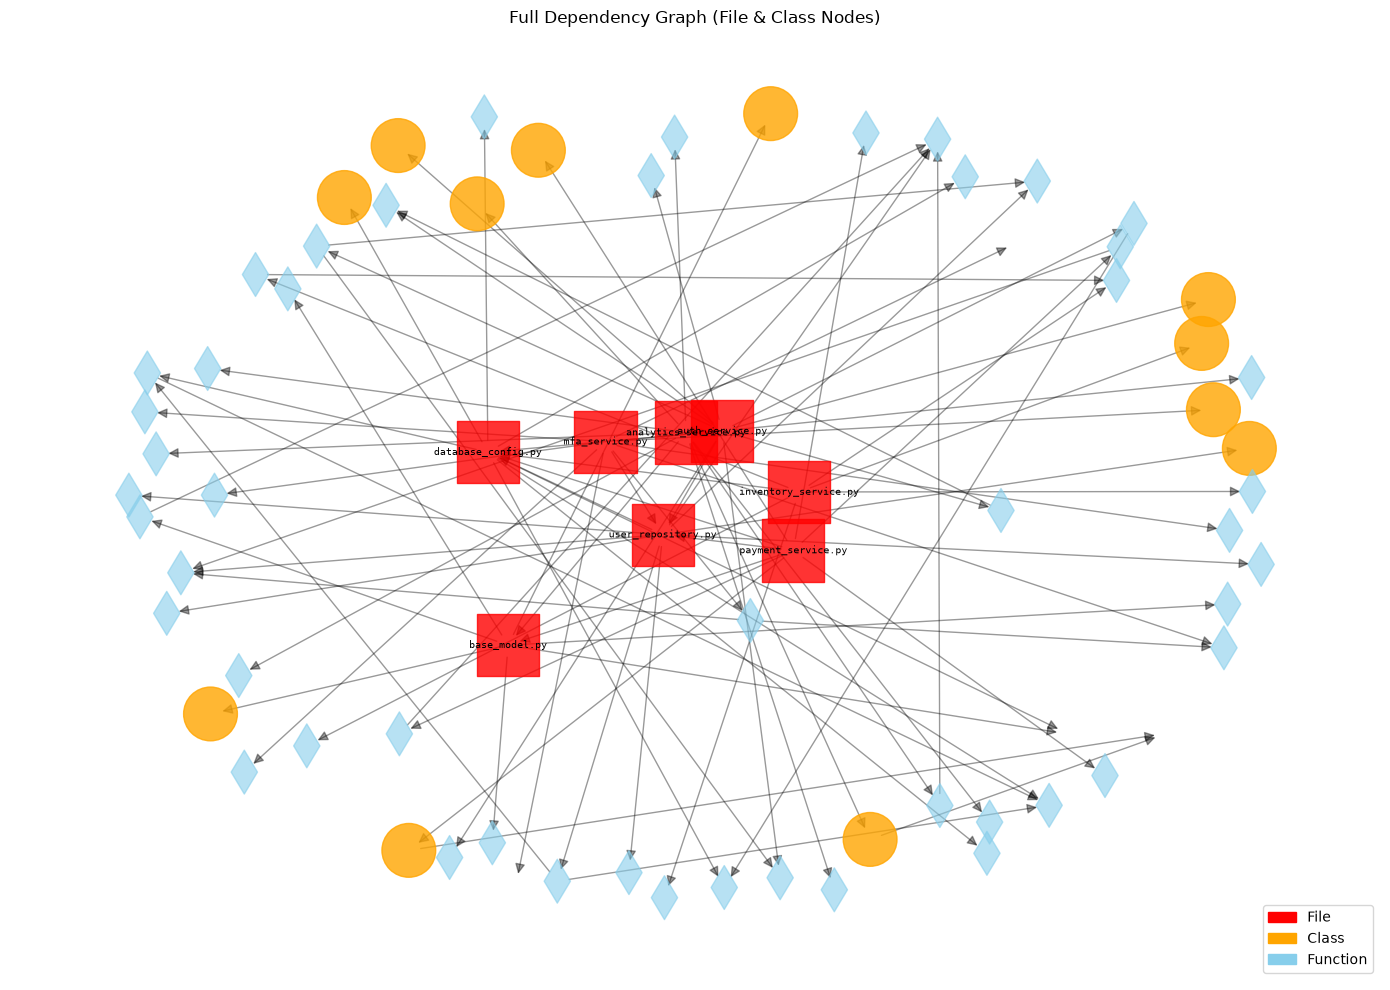


Nodes: 76
Edges: 90
  File nodes: 8
  Class nodes: 12
  Function nodes: 48


In [17]:
# -----------------------------
# Step 3: Visualize full dependency graph
# -----------------------------

plt.figure(figsize=(14, 10))

# Better layout (more spacing)
pos = nx.spring_layout(graph.graph, k=1.2, seed=42)

# Color nodes by type
color_map = []
for node_id in graph.graph.nodes():
    node_type = graph.graph.nodes[node_id].get("node_type", "function")
    if node_type == "file":
        color_map.append("red")
    elif node_type == "class":
        color_map.append("orange")
    else:
        color_map.append("skyblue")

# Draw nodes by type for better visualization
file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "file"]
class_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "class"]
func_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "function"]

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=file_nodes_list,
    node_color=["red" for _ in file_nodes_list],
    node_size=2000,
    node_shape="s",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=class_nodes_list,
    node_color=["orange" for _ in class_nodes_list],
    node_size=1500,
    node_shape="o",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=func_nodes_list,
    node_color=["skyblue" for _ in func_nodes_list],
    node_size=500,
    node_shape="d",
    alpha=0.6,
)

nx.draw_networkx_edges(
    graph.graph, pos,
    arrows=True,
    arrowsize=15,
    alpha=0.4,
)

# Draw labels for file nodes only (keep it readable)
file_labels = {n: n for n in file_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=file_labels,
    font_size=7,
    font_family="monospace",
)

plt.title("Full Dependency Graph (File & Class Nodes)")
plt.axis("off")
file_patch = mpatches.Patch(color='red', label='File')
class_patch = mpatches.Patch(color='orange', label='Class')
func_patch = mpatches.Patch(color='skyblue', label='Function')
plt.legend(handles=[file_patch, class_patch, func_patch], loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nNodes: {graph.node_count}")
print(f"Edges: {graph.edge_count}")
print(f"  File nodes: {len(file_nodes_list)}")
print(f"  Class nodes: {len(class_nodes_list)}")
print(f"  Function nodes: {len(func_nodes_list)}")

In [18]:
# -----------------------------
# Step 4: Run baseline BFS and ACCS with search
# -----------------------------

# Define a query to find relevant nodes (like the CLI does)
QUERY = "implement stripe payment integration"
TOKEN_BUDGET = 500
MAX_DEPTH = 5
TOP_K = 3

print(f"Query: \"{QUERY}\"")
print(f"Token budget: {TOKEN_BUDGET}")
print()

# Find start nodes based on query (same as CLI Step 3)
print("Finding start nodes...")
matches = GraphSearch.search(graph, QUERY)
start_nodes = GraphSearch.find_start_nodes(graph, QUERY, top_k=TOP_K)

if not start_nodes:
    # Fallback: if no matches, use the first file node
    file_nodes_list = graph.get_all_files()
    start_nodes = file_nodes_list[:1] if file_nodes_list else []

print(f"  Found {len(start_nodes)} start node(s):")
for i, sn in enumerate(start_nodes[:TOP_K]):
    node = graph.get_node_data(sn)
    node_type = node.node_type if node else "unknown"
    print(f"    {i+1}. [{node_type}] {sn}")
print()

# Run baseline BFS using production BaselineBFS class
print("Running Baseline BFS retrieval...")
baseline = BaselineBFS(graph, max_depth=MAX_DEPTH)
baseline_result = baseline.retrieve(QUERY, top_k=TOP_K)
baseline_nodes = set(baseline_result.retrieved_nodes)
baseline_tokens = baseline_result.token_estimate.total_tokens
baseline_coverage = DependencyCoverage.calculate(graph, start_nodes, baseline_nodes)

print(f"  Retrieved: {len(baseline_nodes)} nodes")
print(f"  Tokens: {baseline_tokens}")
print(f"  Coverage: {baseline_coverage.coverage_ratio:.2%}")
print()

# Run adaptive ACCS using production AdaptiveBudgetRetriever class
print("Running Adaptive Budget-Aware ACCS retrieval...")
adaptive = AdaptiveBudgetRetriever(
    graph,
    budget=TOKEN_BUDGET,
    max_depth=MAX_DEPTH,
    importance_metric="pagerank",
    force_entry_node=False,
    tokenizer_mode="fast",
    scoring_config=ScoringConfig(None),
)
adaptive_result = adaptive.retrieve(QUERY, top_k=TOP_K)
adaptive_nodes = set(adaptive_result.retrieved_nodes)
adaptive_tokens = adaptive_result.token_estimate.total_tokens
adaptive_coverage = DependencyCoverage.calculate(graph, start_nodes, adaptive_nodes)

print(f"  Retrieved: {len(adaptive_nodes)} nodes")
print(f"  Tokens: {adaptive_tokens}")
print(f"  Coverage: {adaptive_coverage.coverage_ratio:.2%}")
print(f"  Budget remaining: {adaptive_result.budget_remaining}")

Query: "implement stripe payment integration"
Token budget: 500

Finding start nodes...
  Found 3 start node(s):
    1. [file] payment_service.py
    2. [class] payment_service.py::PaymentService
    3. [class] payment_service.py::PaymentLog

Running Baseline BFS retrieval...
  Retrieved: 34 nodes
  Tokens: 1362.0
  Coverage: 100.00%

Running Adaptive Budget-Aware ACCS retrieval...
  Retrieved: 9 nodes
  Tokens: 460.0
  Coverage: 42.86%
  Budget remaining: 40.0


In [19]:
# -----------------------------
# Step 5: Compare results
# -----------------------------

print("\n" + "="*50)
print("  COMPARISON RESULTS")
print("="*50)
print(f"{'Metric':<25} {'Baseline BFS':<20} {'ACCS':<20}")
print("-"*65)

baseline_files = len(baseline_result.retrieved_files)
adaptive_files = len(adaptive_result.retrieved_files)
print(f"{"Retrieved Files":<25} {baseline_files:<20} {adaptive_files:<20}")

print(f"{"Retrieved Nodes":<25} {baseline_tokens:<20} {adaptive_tokens:<20}")

baseline_chars = baseline_result.token_estimate.total_characters
adaptive_chars = adaptive_result.token_estimate.total_characters
print(f"{"Characters":<25} {baseline_chars:<20} {adaptive_chars:<20}")

print(f"{"Estimated Tokens":<25} {baseline_tokens:<20} {adaptive_tokens:<20}")

baseline_cov_ratio = baseline_coverage.coverage_ratio if baseline_coverage else 0
adaptive_cov_ratio = adaptive_coverage.coverage_ratio if adaptive_coverage else 0
baseline_cov_str = f"{baseline_cov_ratio:.2%}" if baseline_cov_ratio else "N/A"
adaptive_cov_str = f"{adaptive_cov_ratio:.2%}" if adaptive_cov_ratio else "N/A"
print(f"{"Dependency Coverage":<25} {baseline_cov_str:<20} {adaptive_cov_str:<20}")

baseline_missing = len(baseline_coverage.missing_nodes) if baseline_coverage else 0
adaptive_missing = len(adaptive_coverage.missing_nodes) if adaptive_coverage else 0
print(f"{"Missing Nodes":<25} {baseline_missing:<20} {adaptive_missing:<20}")

# Context Compression Ratio (CCR)
if baseline_tokens > 0:
    ccr = adaptive_tokens / baseline_tokens
    reduction = (1 - ccr) * 100
    print(f"\nContext Compression Ratio (CCR): {ccr:.2f}")
    if reduction > 0:
        print(f"Token Reduction: {reduction:.1f}% ({baseline_tokens} → {adaptive_tokens} tokens)")
    else:
        print(f"Token Increase: {-reduction:.1f}% ({baseline_tokens} → {adaptive_tokens} tokens)")



  COMPARISON RESULTS
Metric                    Baseline BFS         ACCS                
-----------------------------------------------------------------
Retrieved Files           4                    2                   
Retrieved Nodes           1362.0               460.0               
Characters                5455                 1847                
Estimated Tokens          1362.0               460.0               
Dependency Coverage       100.00%              42.86%              
Missing Nodes             0                    4                   

Context Compression Ratio (CCR): 0.34
Token Reduction: 66.2% (1362.0 → 460.0 tokens)


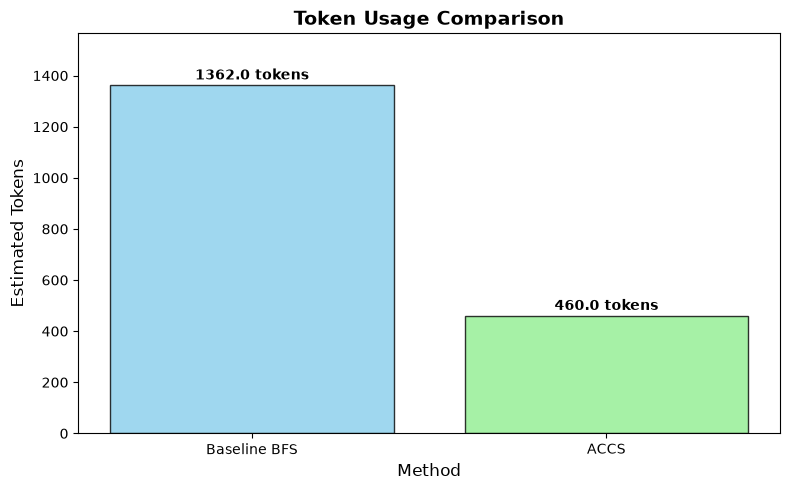

ACCS reduces token usage by 66.2% compared to baseline


In [20]:
# -----------------------------
# Step 6: Visualize token comparison
# -----------------------------

methods = ["Baseline BFS", "ACCS"]
tokens = [baseline_tokens, adaptive_tokens]
colors_bar = ["skyblue", "lightgreen"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, tokens, color=colors_bar, edgecolor="black", alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, tokens):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{val} tokens", ha='center', va='bottom', fontweight='bold')

ax.set_title("Token Usage Comparison", fontsize=14, fontweight='bold')
ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Estimated Tokens", fontsize=12)
ax.set_ylim(0, max(tokens) * 1.15)
plt.tight_layout()
plt.show()

# Show the reduction
if baseline_tokens > 0:
    pct = (1 - adaptive_tokens / baseline_tokens) * 100
    print(f"ACCS reduces token usage by {pct:.1f}% compared to baseline")

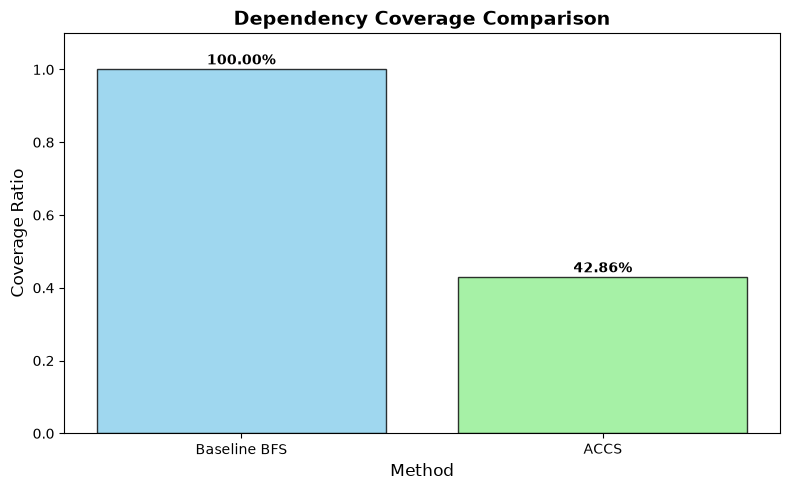

In [21]:
# -----------------------------
# Step 7: Visualize coverage comparison
# -----------------------------

coverage_values = [baseline_cov_ratio, adaptive_cov_ratio]
colors_cov = ["skyblue", "lightgreen"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, coverage_values, color=colors_cov, edgecolor="black", alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, coverage_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.2%}", ha='center', va='bottom', fontweight='bold')

ax.set_title("Dependency Coverage Comparison", fontsize=14, fontweight='bold')
ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Coverage Ratio", fontsize=12)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

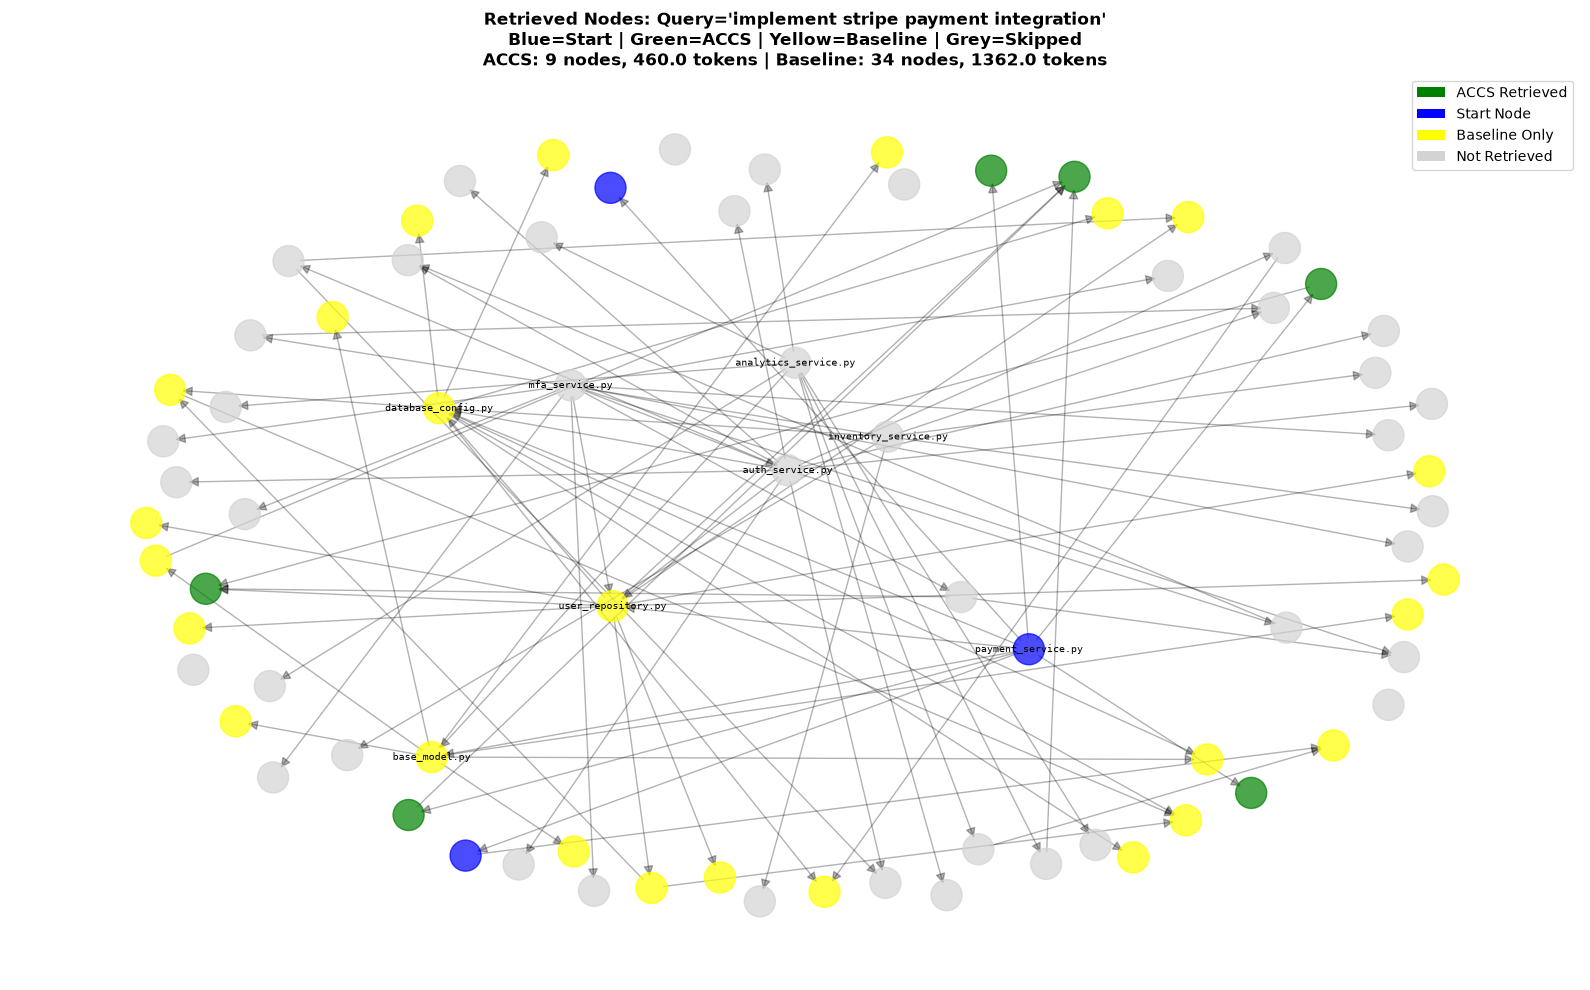

In [22]:
# -----------------------------
# Step 8: Visualize retrieved nodes on graph
# -----------------------------

plt.figure(figsize=(16, 10))
pos = nx.spring_layout(graph.graph, k=1.5, seed=42)

# Color each node based on its status
nodes_list = list(graph.graph.nodes())
node_color_map = {}
for sn in start_nodes:
    node_color_map[sn] = 'blue'
for n in adaptive_nodes:
    if n not in node_color_map:
        node_color_map[n] = 'green'
for n in baseline_nodes:
    if n not in node_color_map:
        node_color_map[n] = 'yellow'
for n in nodes_list:
    if n not in node_color_map:
        node_color_map[n] = 'lightgrey'

final_colors = [node_color_map.get(n, 'lightgrey') for n in nodes_list]

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=nodes_list,
    node_color=final_colors,
    node_size=500,
    alpha=0.7,
)

nx.draw_networkx_edges(
    graph.graph, pos,
    arrows=True,
    arrowsize=15,
    alpha=0.3,
)

# Draw labels for file nodes only
file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get('node_type') == 'file']
file_labels = {n: n for n in file_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=file_labels,
    font_size=7,
    font_family='monospace',
)

plt.title(
    f"Retrieved Nodes: Query='{QUERY}'\n"
    f"Blue=Start | Green=ACCS | Yellow=Baseline | Grey=Skipped\n"
    f"ACCS: {len(adaptive_nodes)} nodes, {adaptive_tokens} tokens | "
    f"Baseline: {len(baseline_nodes)} nodes, {baseline_tokens} tokens",
    fontsize=12, fontweight='bold'
)
plt.axis('off')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='green', label='ACCS Retrieved'),
    mpatches.Patch(facecolor='blue', label='Start Node'),
    mpatches.Patch(facecolor='yellow', label='Baseline Only'),
    mpatches.Patch(facecolor='lightgrey', label='Not Retrieved'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


In [23]:
# -----------------------------
# Step 9: Show retrieved context (sample)
# -----------------------------

# Build context from adaptive result
context_builder = ContextBuilder(tokenizer_mode="fast")
adaptive_context = context_builder.build(list(adaptive_nodes), graph)

print("="*60)
print("ADAPTIVE RETRIEVAL - Context Summary")
print("="*60)
print(f"Query: {QUERY}")
print(f"Budget: {TOKEN_BUDGET} tokens")
print(f"Tokens used: {adaptive_tokens}")
print(f"Nodes retrieved: {len(adaptive_nodes)}")
print(f"Files retrieved: {len(adaptive_result.retrieved_files)}")
print(f"Coverage: {adaptive_cov_ratio:.2%}")
print(f"Missing nodes: {adaptive_missing}")
print()

# Show retrieved files
print("Retrieved files:")
for fpath in sorted(adaptive_result.retrieved_files):
    file_node = graph.get_node_data(fpath)
    tok_cost = file_node.estimated_token_cost if file_node else 0
    print(f"  - {fpath} (~{tok_cost} tokens)")

# Show context snippet
print()
print("Context preview (first 1500 chars):")
print("-"*60)
context_preview = adaptive_context.source[:1500]
print(context_preview)
if len(adaptive_context.source) > 1500:
    print(f"\n... ({len(adaptive_context.source)} total chars)")

ADAPTIVE RETRIEVAL - Context Summary
Query: implement stripe payment integration
Budget: 500 tokens
Tokens used: 460.0
Nodes retrieved: 9
Files retrieved: 2
Coverage: 42.86%
Missing nodes: 4

Retrieved files:
  - payment_service.py (~372 tokens)
  - user_repository.py (~415 tokens)

Context preview (first 1500 chars):
------------------------------------------------------------
--- payment_service.py ---
# class: PaymentService (lines 7-35)
class PaymentService:
    """Handles payment processing and billing."""

    def __init__(self, user_repo: UserRepository, db_config: DatabaseConfig):
        self.user_repo = user_repo
        self.db_config = db_config
        self._transactions = []

    def process_payment(self, user_id: int, amount: float, currency: str = "USD") -> dict:
        """Process a payment transaction."""
        user = self.user_repo.find_by_id(user_id)
        if not user:
            return {"status": "failed", "message": "User not found"}
        transaction = {
 

In [24]:
# -----------------------------
# Step 10: Analysis and Complexity
# -----------------------------

print("\n" + "="*60)
print("  ANALYSIS")
print("="*60)

print("\n### Token Reduction")
if baseline_tokens > 0:
    reduction_pct = (1 - adaptive_tokens / baseline_tokens) * 100
    if reduction_pct > 0:
        print(f"ACCS reduced token usage by {reduction_pct:.1f}% ({baseline_tokens} → {adaptive_tokens} tokens)")
    elif reduction_pct < 0:
        print(f"ACCS used {abs(reduction_pct):.1f}% more tokens than baseline ({baseline_tokens} → {adaptive_tokens})")
        print("This can happen when the baseline BFS over-retrieves while ACCS stays precise.")
    else:
        print("Both algorithms retrieved equivalent context.")

print("\n### Coverage Trade-off")
cov_diff = adaptive_cov_ratio - baseline_cov_ratio
if cov_diff > 0:
    print(f"ACCS has BETTER coverage than baseline (+{cov_diff:.2%})")
elif cov_diff < 0:
    print(f"ACCS has slightly lower coverage (-{abs(cov_diff):.2%}) but with fewer tokens")
else:
    print("Both algorithms achieve identical coverage.")

print("\n### Key Findings")
print("1. ACCS uses priority-queue-based traversal to select high-value nodes")
print("2. Each node is scored using: keyword relevance + dependency importance + centrality + token cost")
print("3. Budget is strictly enforced - nodes exceeding remaining budget are skipped (not the retrieval)")
print("4. The Context Compression Ratio (CCR) = adaptive_tokens / baseline_tokens")
print("5. CCR < 1.0 means ACCS is more efficient at delivering relevant context")

print("\n### Complexity Analysis")
print("Baseline BFS: O(V + E) - simple breadth-first traversal")
print("ACCS:")
print("  - Scoring: O(N) per node")
print("  - Priority queue: O(log N) per insertion")
print("  - Total: O(N log N) with priority queue operations")
print("\nACCS introduces computational overhead but improves inference efficiency")
print("by reducing the token size of context sent to the LLM.")


  ANALYSIS

### Token Reduction
ACCS reduced token usage by 66.2% (1362.0 → 460.0 tokens)

### Coverage Trade-off
ACCS has slightly lower coverage (-57.14%) but with fewer tokens

### Key Findings
1. ACCS uses priority-queue-based traversal to select high-value nodes
2. Each node is scored using: keyword relevance + dependency importance + centrality + token cost
3. Budget is strictly enforced - nodes exceeding remaining budget are skipped (not the retrieval)
4. The Context Compression Ratio (CCR) = adaptive_tokens / baseline_tokens
5. CCR < 1.0 means ACCS is more efficient at delivering relevant context

### Complexity Analysis
Baseline BFS: O(V + E) - simple breadth-first traversal
ACCS:
  - Scoring: O(N) per node
  - Priority queue: O(log N) per insertion
  - Total: O(N log N) with priority queue operations

ACCS introduces computational overhead but improves inference efficiency
by reducing the token size of context sent to the LLM.
